In [ ]:
!pip install -U scikit-learn

from google.colab import files
import pandas as pd
import io
import random
from sklearn.metrics import root_mean_squared_error
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 61.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.1 which is incompatible.


In [ ]:
uploaded = files.upload()
DF = pd.read_excel(io.BytesIO(uploaded['Data Tensorflow TA.xlsx']))
DF = DF.dropna()
DF = DF.drop(columns = ['Tanggal', 'PDA Dayeuhkolot','PDA Baleendah'])

Saving Data Tensorflow TA.xlsx to Data Tensorflow TA.xlsx


In [ ]:
LABEL = DF['Status']
FEATURES = DF.drop(columns = ['Status'])
PCH = FEATURES.columns

train_ratio = 70E-2
TRAIN_FEATURES = FEATURES.iloc[:int(len(DF)*train_ratio)]
TRAIN_LABEL = LABEL.iloc[:int(len(DF)*train_ratio)]
TEST_FEATURES = FEATURES.iloc[int(len(DF)*train_ratio):]
TEST_LABEL = LABEL.iloc[int(len(DF)*train_ratio):]

rfc_rmse_value = 99
gbc_rmse_value = 99

In [ ]:
# Print linear regression model
MODEL_LR = LinearRegression(fit_intercept = True, tol = 0.000166, positive = True)
MODEL_LR.fit(TRAIN_FEATURES, TRAIN_LABEL)
VALUES_LR = (MODEL_LR.coef_/sum(abs(i) for i in MODEL_LR.coef_))*100
PERM_RESULT_LR = permutation_importance(MODEL_LR, TEST_FEATURES, TEST_LABEL, n_repeats = 5)
VALUES_LRP = PERM_RESULT_LR.importances_mean

print("Training score : %f" % MODEL_LR.score(TRAIN_FEATURES, TRAIN_LABEL))
print("Testing score : %f" % MODEL_LR.score(TEST_FEATURES, TEST_LABEL))
print("RMSE : %f" % root_mean_squared_error(TEST_LABEL, MODEL_LR.predict(TEST_FEATURES)))

# Print random forest model
MODEL_RFC = RandomForestClassifier(n_estimators = 237, criterion = 'gini', max_depth = 9, min_samples_split = 24, min_samples_leaf = 19, min_weight_fraction_leaf = 0.009760000000000001, min_impurity_decrease = 0.000265, ccp_alpha = 0.000598,
                                   max_samples = 5773, random_state = 0)
MODEL_RFC.fit(TRAIN_FEATURES, TRAIN_LABEL)
VALUES_RFC = MODEL_RFC.feature_importances_*100
PERM_RESULT_RFC = permutation_importance(MODEL_RFC, TEST_FEATURES, TEST_LABEL, n_repeats = 5)
VALUES_RFP = PERM_RESULT_RFC.importances_mean

print("Training score : %f" % MODEL_RFC.score(TRAIN_FEATURES, TRAIN_LABEL))
print("Testing score : %f" % MODEL_RFC.score(TEST_FEATURES, TEST_LABEL))
print("RMSE : %f" % root_mean_squared_error(TEST_LABEL, MODEL_RFC.predict(TEST_FEATURES)))

Training score : 0.007070
Testing score : -0.405671
RMSE : 1.200415
Training score : 0.463678
Testing score : 0.308113
RMSE : 1.329785


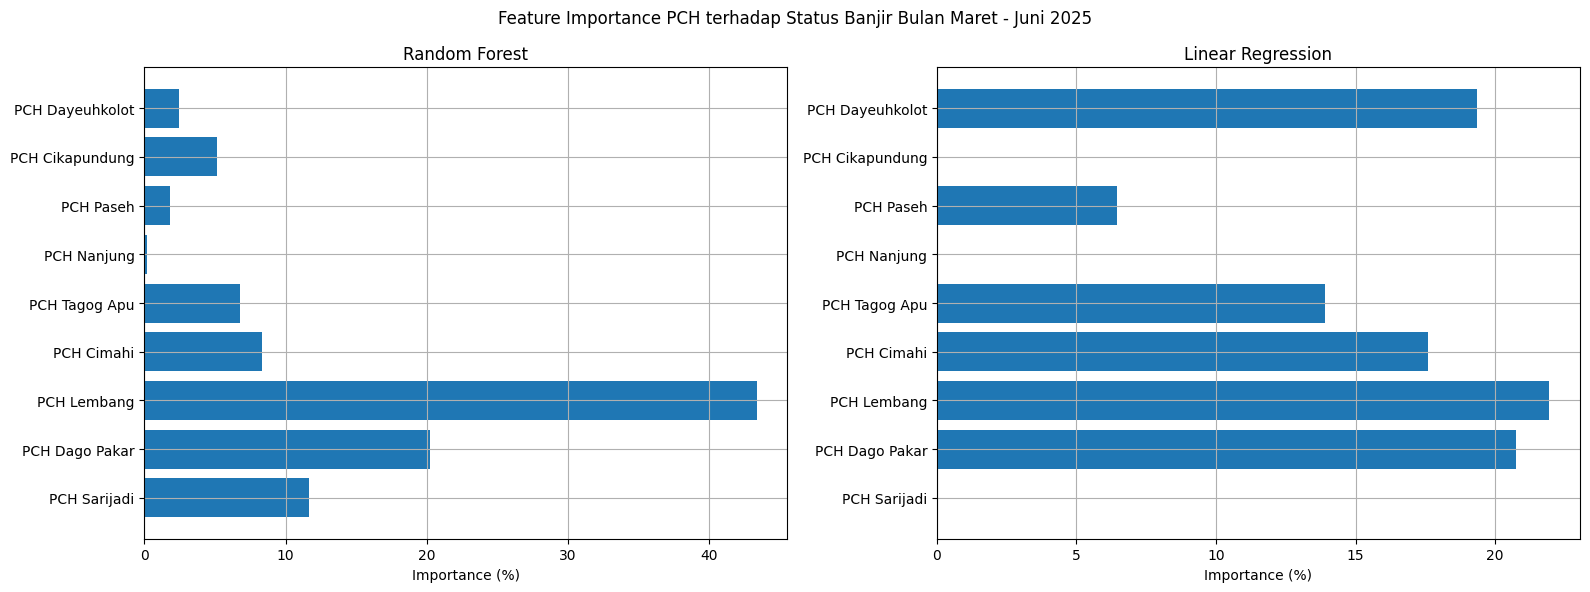

In [ ]:
fig = plt.figure(figsize = (16, 6))
fig.suptitle("Feature Importance PCH terhadap Status Banjir Bulan Maret - Juni 2025")
ax = fig.subplots(1, 2)

ax[0].barh(PCH, VALUES_RFC)
ax[0].set_title("Random Forest")
ax[0].set_xlabel("Importance (%)")
ax[0].grid()

ax[1].barh(PCH, VALUES_LR)
ax[1].set_title("Linear Regression")
ax[1].set_xlabel("Importance (%)")
ax[1].grid()

plt.tight_layout()
plt.show()